<a href="https://colab.research.google.com/github/jbrazonath/Desafios-NLP/blob/main/Desafio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.1 MB/s eta 0:00:00


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [2]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

--2026-03-26 21:33:39--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-03-26 21:33:39--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-03-26 21:33:39--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.

In [3]:
# Posibles bandas
os.listdir("./songs_dataset/")

['janisjoplin.txt',
 'notorious-big.txt',
 'bruno-mars.txt',
 'adele.txt',
 'lady-gaga.txt',
 'cake.txt',
 'joni-mitchell.txt',
 'lorde.txt',
 'bjork.txt',
 'leonard-cohen.txt',
 'Kanye_West.txt',
 'eminem.txt',
 'beatles.txt',
 'rihanna.txt',
 'patti-smith.txt',
 'paul-simon.txt',
 'prince.txt',
 'michael-jackson.txt',
 'r-kelly.txt',
 'johnny-cash.txt',
 'dj-khaled.txt',
 'alicia-keys.txt',
 'bob-marley.txt',
 'blink-182.txt',
 'nicki-minaj.txt',
 'al-green.txt',
 'britney-spears.txt',
 'missy-elliott.txt',
 'amy-winehouse.txt',
 'nirvana.txt',
 'ludacris.txt',
 'bruce-springsteen.txt',
 'kanye-west.txt',
 'disney.txt',
 'nursery_rhymes.txt',
 'drake.txt',
 'dickinson.txt',
 'radiohead.txt',
 'jimi-hendrix.txt',
 'bob-dylan.txt',
 'notorious_big.txt',
 'lin-manuel-miranda.txt',
 'nickelback.txt',
 'dolly-parton.txt',
 'Lil_Wayne.txt',
 'kanye.txt',
 'dr-seuss.txt',
 'lil-wayne.txt',
 'bieber.txt']

In [26]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/adele.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_17741/1435157082.py:2: ParserWarning:

Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.



,0
0,Looking for some education
1,Made my way into the night
2,All that bullshit conversation
3,"Baby, can't you read the signs? I won't bore y..."
4,I don't even wanna waste your time


In [27]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 2400


### 1 - Preprocesamiento

In [28]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [50]:
# Demos un vistazo
sentence_tokens[:2]

[['looking', 'for', 'some', 'education'],
 ['made', 'my', 'way', 'into', 'the', 'night']]

### 2 - Crear los vectores (word2vec)

In [30]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [31]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [32]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [33]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 2400


In [34]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 516


### 3 - Entrenar embeddings

In [35]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 156209.484375
Loss after epoch 1: 94109.078125
Loss after epoch 2: 92977.09375
Loss after epoch 3: 92847.03125
Loss after epoch 4: 92891.375
Loss after epoch 5: 94219.625
Loss after epoch 6: 92026.25
Loss after epoch 7: 88892.75
Loss after epoch 8: 87158.9375
Loss after epoch 9: 85004.125
Loss after epoch 10: 81242.0
Loss after epoch 11: 72698.875
Loss after epoch 12: 71127.375
Loss after epoch 13: 70583.0
Loss after epoch 14: 70164.25
Loss after epoch 15: 68965.75
Loss after epoch 16: 68198.0
Loss after epoch 17: 68041.125
Loss after epoch 18: 68427.0
Loss after epoch 19: 67699.25


(218266, 380480)

### 4 - Ensayar

In [37]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["someone"], topn=10)

[('believe', 0.9553000330924988),
 ('an', 0.9200541973114014),
 ('yourself', 0.9196509122848511),
 ('seem', 0.9101039171218872),
 ('must', 0.9063895344734192),
 ('run', 0.9017786383628845),
 ('umm', 0.9012755751609802),
 ('bare', 0.8953800201416016),
 ('home', 0.8929700255393982),
 ('falling', 0.8919448256492615)]

Seleccioné Adele para mi entrenamiento, dado que ella suele cantar acerca de amor, despedidas y temas melancolicos, ver que la palabra "believe" es la que mas se relaciona con Someone tiene sentido.

In [38]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('river', -0.17185866832733154),
 ('could', -0.17905180156230927),
 ('beside', -0.19516606628894806),
 ('lea', -0.19837601482868195),
 ('away', -0.2077217698097229),
 ('skyfall', -0.20903022587299347),
 ('way', -0.21458208560943604),
 ('wish', -0.22003796696662903),
 ('down', -0.22616197168827057),
 ('stand', -0.22825898230075836)]

Las que menos se relacionan con Love también son esperadas, no tienen nada que ver con la palabra seleccionada.

In [53]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["wish"], topn=10)

[('met', 0.8239374756813049),
 ('call', 0.7922518849372864),
 ('home', 0.752392590045929),
 ('whenever', 0.7481702566146851),
 ('woulda', 0.7388439774513245),
 ('true', 0.7386277318000793),
 ('leave', 0.7298919558525085),
 ('never', 0.7291278839111328),
 ('live', 0.7288339138031006),
 ('believe', 0.7284708619117737)]

En el mismo orden de ideas, seleccionando "Wish" y ver que met y cal son las mas relacionadas seguimos con el tema del romance y en este caso deseos, como home y true.

In [54]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["hello"], topn=5)

[('dust', 0.9763898253440857),
 ('outside', 0.9711617827415466),
 ('grow', 0.9667341113090515),
 ('keeps', 0.9498661160469055),
 ('found', 0.9479862451553345)]

En este caso seleccioné Hello porque ella tiene una canción que se llama así, no sé muy bien porqué la relacionó con dust (puede ser por algun tema que estoy olvidando) pero si entendería la relación con outside y las demás

In [55]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["mistery"])

KeyError: "Key 'mistery' not present in vocabulary"

La palabra Mistery no aparece en ninguna de sus letras

In [43]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 3.21698859e-02  2.06260949e-01  4.13409211e-02  1.03466414e-01
  9.90877375e-02 -3.25424910e-01  1.74942210e-01  1.46959335e-01
  4.32413630e-03 -1.13137485e-02  5.66662960e-02 -1.83240622e-01
  2.57915463e-02 -8.59604627e-02 -1.95308611e-01 -3.14244419e-01
  1.03517115e-01  2.83816047e-02  4.98049073e-02 -7.93439075e-02
 -7.01561123e-02 -2.35760864e-02 -7.74854347e-02  2.35042125e-01
 -6.04480412e-03  9.23881009e-02 -1.40098676e-01 -9.82186049e-02
 -1.84696674e-01 -3.01699609e-01  1.74750179e-01  1.09220751e-01
  1.44509628e-01  1.07212812e-01  1.63919404e-01  3.05301577e-01
  1.02469288e-01  4.57663871e-02 -1.28188863e-01  1.04881432e-02
 -2.05772892e-01 -3.52236539e-01 -2.58624822e-01 -2.12698966e-01
  1.41171282e-02  7.13763461e-02  4.34731960e-01 -7.21071810e-02
  3.38364430e-02 -5.91510274e-02  3.37456584e-01 -2.16247022e-01
  1.98056206e-01  2.66948521e-01  1.45094320e-01  2.11739317e-01
  3.63671370e-02 -1.07193299e-01 -1.95727590e-02  2.01741099e-01
  2.91571677e-01 -1.91434

In [57]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 1.0000001192092896),
 ('forgive', 0.8250524997711182),
 ('first', 0.8049468398094177),
 ("that's", 0.7882559895515442),
 ('do', 0.7501065135002136),
 ('cry', 0.7444002628326416),
 ('knows', 0.7370840907096863),
 ('send', 0.7304920554161072),
 ('crazy', 0.725854218006134),
 ('want', 0.7163442373275757)]

Acorde a la temática que suele tocar Adele, el 'amor' no se relaciona con palabras puramente positivas o de felicidad absoluta, sino que tambien abarca temáticas de sufrimiento, pena y duelo. El hecho de que sus similitudes directas sean 'forgive' y 'cry' refleja que en sus canciones el amor se emplea en contextos nostálgicos o dolorosos.

In [56]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["tears"], topn=10)

[('rolling', 0.8971807360649109),
 ('are', 0.8954513072967529),
 ("rollin'", 0.8880727291107178),
 ('wonders', 0.8781588077545166),
 ('deep', 0.849500834941864),
 ('fall', 0.8473848700523376),
 ('days', 0.8364778161048889),
 ('dark', 0.8144583702087402),
 ('walls', 0.7904996871948242),
 ('worlds', 0.7898375391960144)]

A diferencia del análisis anterior donde se captaba un concepto general, aquí podemos ver cómo la arquitectura Word2Vec asimiló estrofas representativas clásicas del artista. La fuerte asociación de 'tears', 'rolling' y 'deep' demuestra que el modelo capturó el contexto de la cancion 'Rolling in the Deep', e infirió que la acción natural de las lágrimas es caer ('fall') en momentos oscuros ('dark'). El modelo aprendió eficientemente los modismos recurrentes con los que Adele canta sobre la tristeza y nostaligia.



### 5 - Visualizar agrupación de vectores

In [46]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [47]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [48]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [49]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

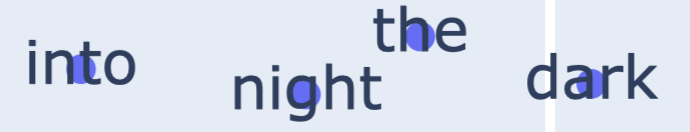


Ya con el análisis previo, y viendo este pequeño cluster de la imagen podemos intuir que el modelo aprendió de la nostalgia de Adele, y en este caso hay una relación de dos palabras claves "night" y "dark"

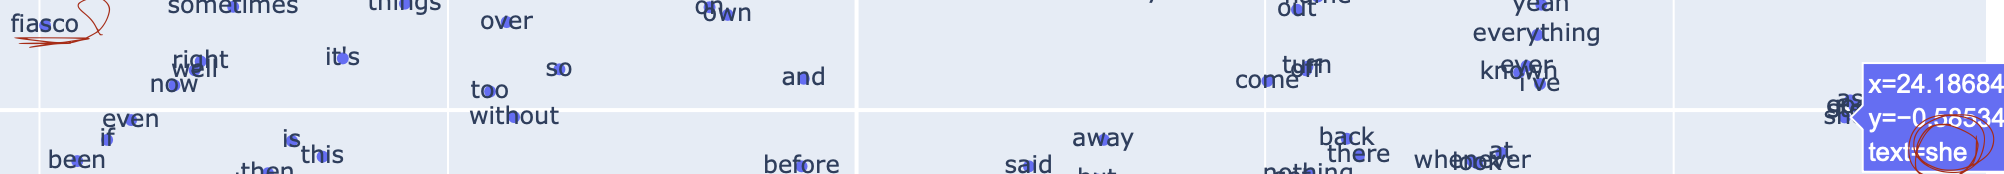

A su vez podemos ver que como palabras lejanas, menos relacionadas están "she" y "fiasco" lo cual sigue la idea de la mujer nostalgia pero no la lleva a algo negatico, estando la misma relativamente cerca de la palabra Everything

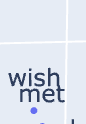

Seguimos viendo el deseo de amor y de conocer a alguien, proyectado por Adele en sus canciones

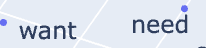